# Business Insights

Business insights are meaningful conclusions obtained by analyzing data and visualizations. The goal is not only to describe what a graph shows, but also to explain what the observation means and why it is important.

For the Titanic dataset, this notebook focuses on identifying important patterns, relationships, anomalies, interesting passenger segments, potential problems, and useful opportunities based on the previous EDA.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Survival Pattern

### Concept
A survival pattern shows how passengers were distributed between those who survived and those who did not survive.

### Example
In a customer dataset, this could be similar to comparing customers who purchased a product with those who did not.

### Interpretation
The survival distribution helps us understand whether the target variable is balanced or imbalanced.

### Insight
If one survival outcome occurs much more frequently than the other, this indicates class imbalance in the dataset.

### AI/ML Relevance
Understanding the target distribution is important because an imbalanced target can affect the performance of classification models.

Survived
0    549
1    342
Name: count, dtype: int64


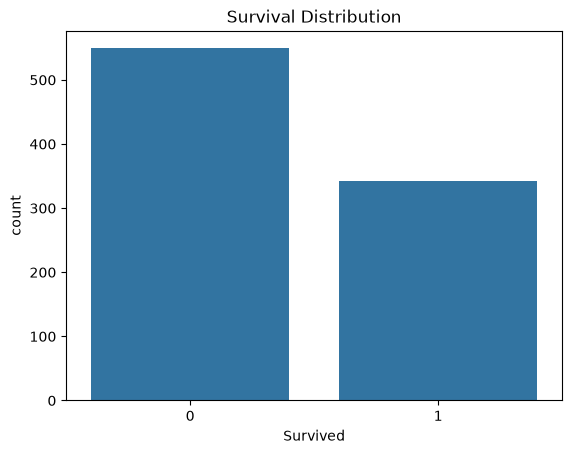

In [2]:
survival_counts = df["Survived"].value_counts()

print(survival_counts)

sns.countplot(data=df, x="Survived")
plt.title("Survival Distribution")
plt.show()

## 2. Relationship Between Gender and Survival

### Concept
This analysis compares survival rates between male and female passengers.

### Example
In business, this is similar to comparing customer behavior between different customer groups.

### Interpretation
The comparison helps us identify whether gender had a relationship with the probability of survival.

### Insight
Female passengers generally had a higher survival rate than male passengers. This suggests that gender was an important factor associated with survival.

### AI/ML Relevance
The `Sex` feature may be a useful predictor for building a survival classification model. Since it is categorical, it must be encoded before being used in most Machine Learning models.

Survived      0      1
Sex                   
female    25.80  74.20
male      81.11  18.89


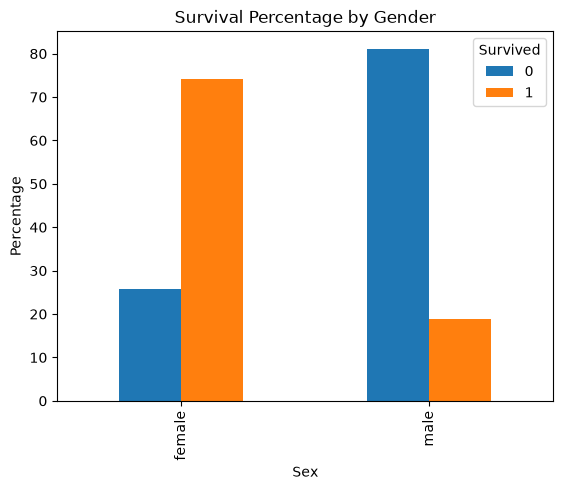

In [3]:
gender_survival = pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
) * 100

print(gender_survival.round(2))

gender_survival.plot(kind="bar")
plt.title("Survival Percentage by Gender")
plt.ylabel("Percentage")
plt.show()

## 3. Passenger Class and Survival

### Concept
Passenger class can be analyzed to understand whether social or economic class was associated with survival.

### Example
In a business dataset, this is similar to comparing customer outcomes across premium, standard, and basic service categories.

### Interpretation
Different survival rates across passenger classes indicate that passenger class had a relationship with survival.

### Insight
Higher passenger classes generally had better survival outcomes than lower passenger classes. This makes `Pclass` an important passenger segment for further analysis.

### AI/ML Relevance
`Pclass` may contain useful predictive information and can also interact with other features such as fare and age.

Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


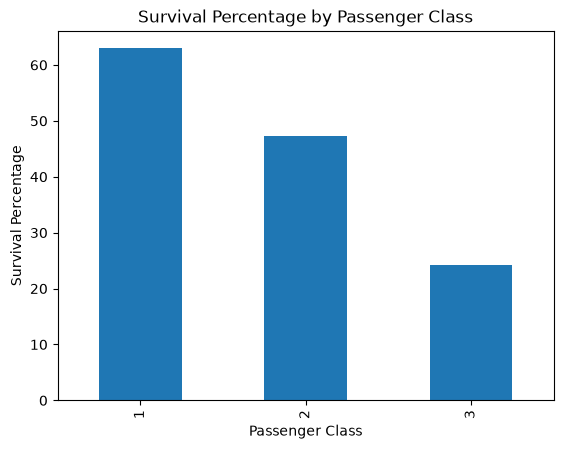

In [4]:
class_survival = df.groupby("Pclass")["Survived"].mean() * 100

print(class_survival.round(2))

class_survival.plot(kind="bar")
plt.title("Survival Percentage by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Percentage")
plt.show()

## 4. Fare Pattern Across Passenger Classes

### Concept
This analysis studies how ticket fares vary across different passenger classes.

### Example
In business, this is similar to comparing the spending level of customers across different membership categories.

### Interpretation
A difference in fare distribution between classes indicates that passenger class and fare are related.

### Insight
Higher passenger classes generally paid higher fares. This shows that `Fare` and `Pclass` contain related information about passenger status.

### AI/ML Relevance
Highly related features should be examined carefully because they may provide overlapping information to a Machine Learning model.

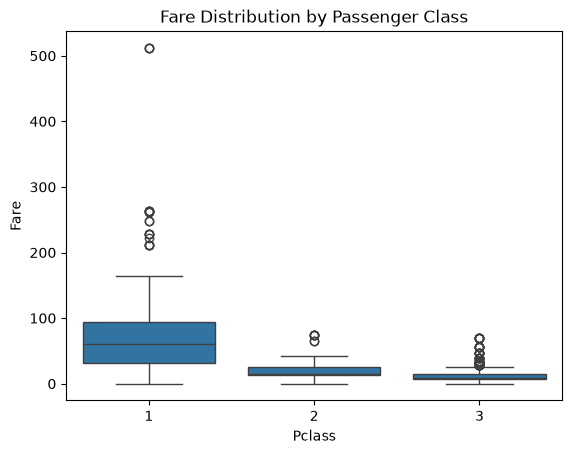

In [5]:
sns.boxplot(data=df, x="Pclass", y="Fare")
plt.title("Fare Distribution by Passenger Class")
plt.show()

## 5. Age and Survival

### Concept
Age can be analyzed to understand whether survival outcomes differed across different age groups.

### Example
In business, age analysis can be used to identify how different customer age segments behave.

### Interpretation
Differences in the age distribution of survivors and non-survivors may indicate that age had some relationship with survival.

### Insight
Age may provide useful information, but the relationship should be considered together with other features such as gender and passenger class.

### AI/ML Relevance
Age is a numerical feature that may be useful for prediction. Missing values should be handled before using it in a Machine Learning model.

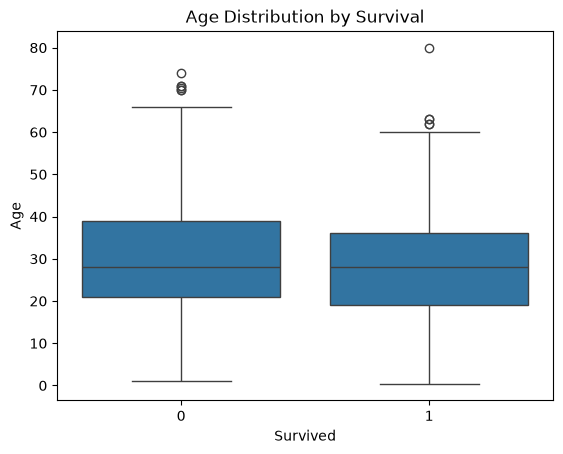

In [6]:
sns.boxplot(data=df, x="Survived", y="Age")
plt.title("Age Distribution by Survival")
plt.show()

## 6. Family Size Pattern

### Concept
The `SibSp` and `Parch` columns can be combined to understand the number of family members travelling with a passenger.

### Example
In business, this is similar to combining related features to create a more meaningful customer segment.

### Interpretation
Family size can help identify whether passengers travelling alone or with family had different survival outcomes.

### Insight
Family-related features may provide additional information that is not immediately visible when `SibSp` and `Parch` are analyzed separately.

### AI/ML Relevance
Creating a `FamilySize` feature is an example of feature engineering, which can sometimes improve Machine Learning model performance.

In [7]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

family_survival = df.groupby("FamilySize")["Survived"].mean() * 100

print(family_survival.round(2))

FamilySize
1     30.35
2     55.28
3     57.84
4     72.41
5     20.00
6     13.64
7     33.33
8      0.00
11     0.00
Name: Survived, dtype: float64


## 7. Interesting Passenger Segments

### Concept
Segmentation divides passengers into meaningful groups so that differences between groups can be identified.

### Example
A company may segment customers based on age, spending, location, or membership type.

### Interpretation
Combining features such as gender and passenger class can reveal stronger patterns than analyzing one feature alone.

### Insight
The survival outcome can vary significantly across combinations of gender and passenger class. These segments provide a deeper understanding of passenger survival patterns.

### AI/ML Relevance
Feature interactions can help Machine Learning models capture relationships that are not visible when features are considered independently.

Sex     female   male
Pclass               
1        96.81  36.89
2        92.11  15.74
3        50.00  13.54


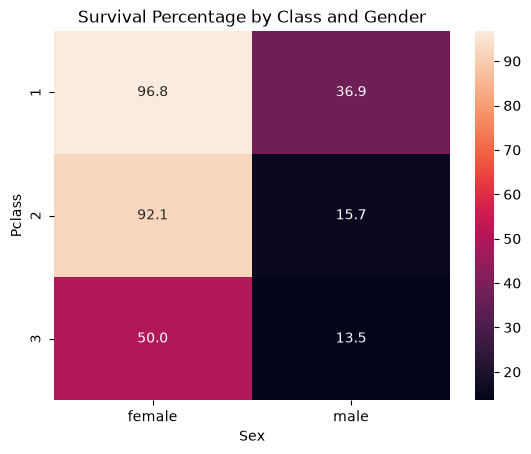

In [8]:
segment_survival = pd.crosstab(
    df["Pclass"],
    df["Sex"],
    values=df["Survived"],
    aggfunc="mean"
) * 100

print(segment_survival.round(2))

sns.heatmap(segment_survival, annot=True, fmt=".1f")
plt.title("Survival Percentage by Class and Gender")
plt.show()

## 8. Anomalies and Potential Data Problems

### Concept
Anomalies are observations or data conditions that require additional attention. They may be genuine observations, data-entry issues, or missing information.

### Example
In a sales dataset, an extremely large transaction may be a genuine high-value purchase or a data-entry error.

### Interpretation
The Titanic dataset contains missing values and features with unusually high numbers of unique values, such as passenger names and ticket numbers.

### Insight
Not every unusual value should be removed. Each observation should be investigated before making a decision.

### AI/ML Relevance
Data quality issues, missing values, and irrelevant identifier-like columns should be handled carefully before model training.

In [9]:
print("Missing Values:")
print(df.isnull().sum())

print("\nUnique Values:")
print(df.nunique())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
dtype: int64

Unique Values:
PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
FamilySize       9
dtype: int64


## 9. Final Business Insights

Based on the analysis, several important observations can be made:

1. Survival was not equally distributed between the two target classes.
2. Gender showed a strong relationship with survival.
3. Passenger class was also associated with survival outcomes.
4. Fare and passenger class showed a clear relationship.
5. Age may provide useful information when analyzed together with other features.
6. Family-related features can be combined to create more meaningful passenger segments.
7. Missing values and identifier-like columns require attention before Machine Learning.

The main objective of this analysis is to move from visualization to observation and finally to meaningful insight.

In [10]:
print("Key Insights from the Titanic Dataset")

print("\nSurvival Rate:", round(df["Survived"].mean() * 100, 2), "%")
print("\nSurvival Rate by Gender:")
print((df.groupby("Sex")["Survived"].mean() * 100).round(2))

print("\nSurvival Rate by Passenger Class:")
print((df.groupby("Pclass")["Survived"].mean() * 100).round(2))

Key Insights from the Titanic Dataset

Survival Rate: 38.38 %

Survival Rate by Gender:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

Survival Rate by Passenger Class:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


# Conclusion

The Titanic dataset shows that survival was influenced by several passenger characteristics rather than a single factor. Gender and passenger class showed particularly important relationships with survival, while age, fare, and family-related features provided additional information.

The analysis also identified data quality considerations such as missing values and high-cardinality or identifier-like columns.

These insights can now support the next stage of the project, where the data can be cleaned, transformed, engineered into useful features, and prepared for Machine Learning models.